# **Perguntas a responder:**

1. Os 5 órgãos com maior custo total?
2. Os 3 destinos com maior custo médio por viagem?
3. A viagem de maior duração e seu custo total?
4. Qual o tipo de pagamento com maior valor médio?
5. Qual o meio de transporte mais usado nos trechos?
6. Qual UF de destino aparece em mais trechos?
7. Qual órgão pagou mais no total?

### **Importações e Criação de funções**


In [3]:
import sys
from pathlib import Path

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ))

from database import banco
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import squarify
import dataframe_image as dfi

PASTA_RAIZ = Path.cwd().parent
PASTA_SQL_GOLD = PASTA_RAIZ / "sql" / "gold"
PASTA_IMAGE =  PASTA_RAIZ / "img"

lista_perguntas = [
    ("pergunta_1", "top5_orgaos_custo_total"),
    ("pergunta_2", "top3_destinos_custo_medio"),
    ("pergunta_3", "viagem_maior_duracao"),
    ("pergunta_4", "tipo_pagamento_valor_medio"),
    ("pergunta_5", "meio_transporte_utilizacao"),
    ("pergunta_6", "destino_uf_frequencia"),
    ("pergunta_7", "orgaos_pagadores_custo_total"),
    ("pergunta_8", "meio_transporte_maior_custo_medio_viagem"),
    ("pergunta_9", "destinos_maior_custo_total"),
    ("pergunta_10", "viajantes_maior_custo_total")
]

# Ajustando a visuaçização do Pandas, devido aos valores serem altos e acabarem dificultando a visualização
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [4]:
def carregar_sql(caminho):
    """
    Lê um arquivo .sql e retorna seu conteúdo como texto.

    O SQL retornado pode ser utilizado para executar consultas,
    criar tabelas, views ou outras instruções no banco de dados.

    Args:
        caminho (str | Path): Caminho do arquivo SQL.

    Returns:
        str: Texto contendo o comando SQL.
    """
    with open(caminho, "r", encoding="utf-8") as arquivo:
        return arquivo.read()

In [5]:
def criar_gold_view(pergunta):
    """
    Cria uma tabela e uma view na camada Gold a partir de uma consulta SQL.

    A função obtém o nome do arquivo SQL e o nome da tabela correspondente
    com base no índice informado, carrega a consulta SQL armazenada na pasta
    de scripts da camada Gold e recria a tabela e a view no banco de dados.
    Caso já existam, a tabela e a view são removidas antes da criação.

    Args:
        pergunta (int): Índice da pergunta de negócio utilizada para
            identificar o arquivo SQL e o nome da tabela Gold.

    Raises:
        Exception: Repassa qualquer exceção ocorrida durante a conexão com o
            banco de dados ou na execução dos comandos SQL.

    Returns:
        None
    """
    nome_sql = lista_perguntas[pergunta-1][0]
    nome_tabela = lista_perguntas[pergunta-1][1]

    try:
        conexao = banco.conectar()
        caminho_sql = PASTA_SQL_GOLD / f"{nome_sql}.sql"
        sql = carregar_sql(caminho_sql)
        print(f"Criando a GOLD da tabela gold_{nome_tabela}")
        banco.executar(conexao, f"DROP TABLE IF EXISTS gold_{nome_tabela}")
        banco.executar(conexao, f"CREATE TABLE gold_{nome_tabela} AS {sql}")

        print(f"Criando a VIEW da tabela {nome_tabela}")
        banco.executar(conexao, f"DROP VIEW IF EXISTS vw_{nome_tabela}")
        banco.executar(conexao, f"CREATE VIEW vw_{nome_tabela} AS {sql}")
            

    except Exception as erro:
        print("[ERRO] Algo deu errado:", erro)
        raise

    finally:
        if conexao:
            conexao.close()
    

In [6]:
def analisar(pergunta):
    """
    Executa uma consulta SQL da camada Gold e retorna o resultado em um DataFrame.

    A função estabelece conexão com o banco de dados, carrega o arquivo SQL
    correspondente à pergunta de negócio informada, executa a consulta e
    armazena o resultado em um DataFrame do pandas. A conexão é encerrada
    automaticamente ao final da execução, mesmo em caso de erro.

    Args:
        pergunta (int): Índice da pergunta de negócio utilizada para
            identificar o arquivo SQL a ser executado.

    Returns:
        pandas.DataFrame: DataFrame contendo o resultado da consulta SQL.

    Raises:
        Exception: Repassa qualquer exceção ocorrida durante a conexão com o
            banco de dados, leitura do arquivo SQL ou execução da consulta.
    """
    conexao = None
    try:
        conexao = banco.conectar()
        caminho_sql = PASTA_SQL_GOLD / f"{lista_perguntas[pergunta-1][0]}.sql"
        sql = carregar_sql(caminho_sql)
        df = pd.read_sql(sql, conexao)

    except Exception as erro:
        print("[ERRO] Algo deu errado:", erro)
        raise

    finally:
        if conexao:
            conexao.close()

    return df

# **Início das análises**

### Pergunta_1: Os 5 órgãos com maior custo total?

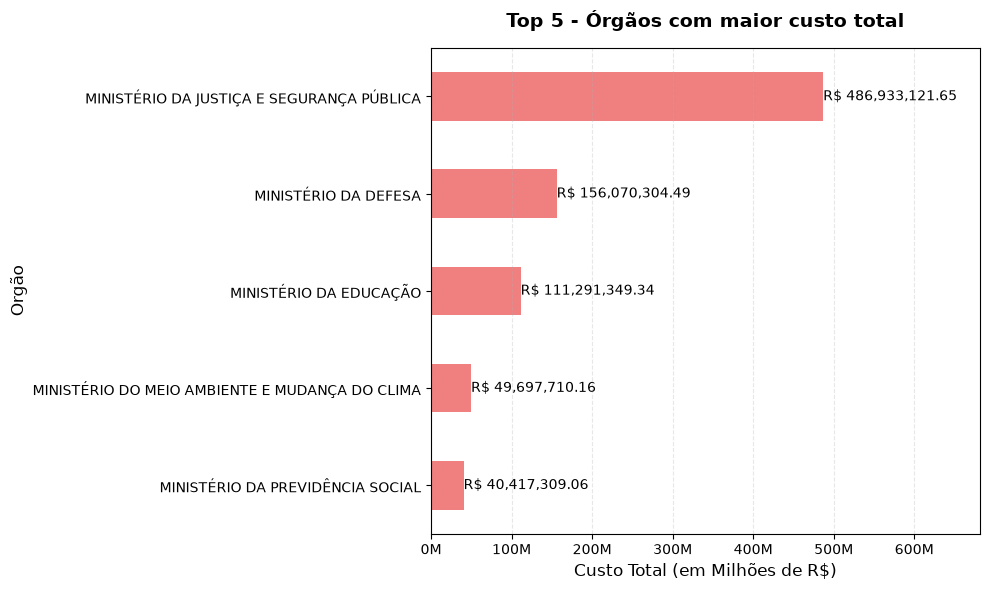

************************************************************************************************************************
                                               Exibição do Datrame Gerado                                                


In [7]:
## Chamada da Função Analisar para a Pergunta 1
df = analisar(1)

## Inicio da criação do gráfico

df = df.sort_values(by="custo_total", ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
df.plot.barh(x="nome_orgao_superior", y="custo_total", ax=ax, color="lightcoral", legend=False)

max_valor = df['custo_total'].max()
ax.set_xlim(0, max_valor * 1.4)

def milhoes_formatter(x, pos):
    return f'{x * 1e-6:.0f}M'
ax.xaxis.set_major_formatter(ticker.FuncFormatter(milhoes_formatter))

ax.set_title(
    "Top 5 - Órgãos com maior custo total", fontsize=14, fontweight="bold", pad=15
)
for i, valor in enumerate(df["custo_total"]):
    ax.text(valor, i, f"R$ {valor:,.2f}", va="center", ha="left")

ax.set_xlabel("Custo Total (em Milhões de R$)", fontsize=12)
ax.set_ylabel("Orgão", fontsize=12)
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PASTA_IMAGE}/grafico_1.png', dpi=300, bbox_inches='tight')
plt.show()


## Apresentação do DF através do print e salvar em forma de imagem
print("".center(120, "*"))
print("Exibição do Datrame Gerado".center(120), "")
df.sort_values(by="custo_total", ascending=False)
dfi.export(
    df.sort_values(by="custo_total", ascending=False),
    f'{PASTA_IMAGE}/df_pergunta_1.png',
    table_conversion="matplotlib"
)

### Pergunta_2: Os 3 destinos com maior custo médio por viagem?

Criando a GOLD da tabela gold_top3_destinos_custo_medio
Criando a VIEW da tabela top3_destinos_custo_medio


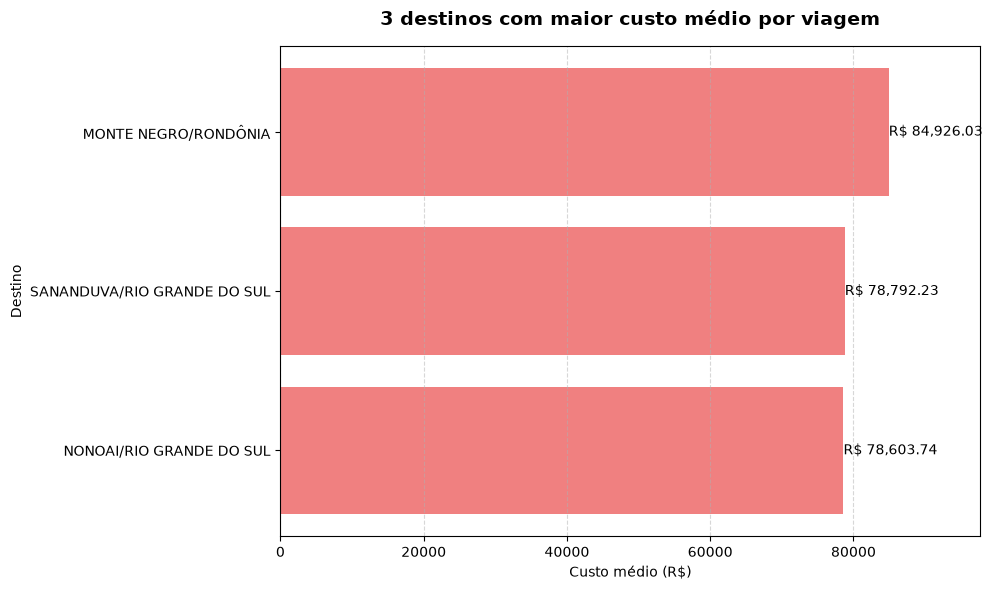

************************************************************************************************************************
                                               Exibição do Datrame Gerado                                                


In [8]:
## Chamada da Função Analisar para a Pergunta 2
df = analisar(2)

## Criando tabela Gold e View
criar_gold_view(2)

## Criação do Gráfico

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df["destino"], df["custo_medio"], color="lightcoral")
ax.invert_yaxis()
ax.set_title("3 destinos com maior custo médio por viagem", fontsize=14, weight="bold", pad=15)
ax.set_xlabel("Custo médio (R$)")
ax.set_ylabel("Destino")
for i, valor in enumerate(df["custo_medio"]):
    ax.text(valor, i, f"R$ {valor:,.2f}", va="center", ha="left")
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.set_xlim(0, df["custo_medio"].max() * 1.15)
plt.tight_layout()
plt.savefig(f'{PASTA_IMAGE}/grafico_2.png', dpi=300, bbox_inches='tight')
plt.show()

## Apresentação do DF através do print e salvar em forma de imagem

print("".center(120, "*"))
print("Exibição do Datrame Gerado".center(120), "")
df.sort_values(by="custo_medio", ascending=False)
dfi.export(
    df.sort_values(by="custo_medio", ascending=False),
    f'{PASTA_IMAGE}/df_pergunta_2.png',
    table_conversion="matplotlib"
)


### Pergunta_3: A viagem de maior duração e seu custo total?


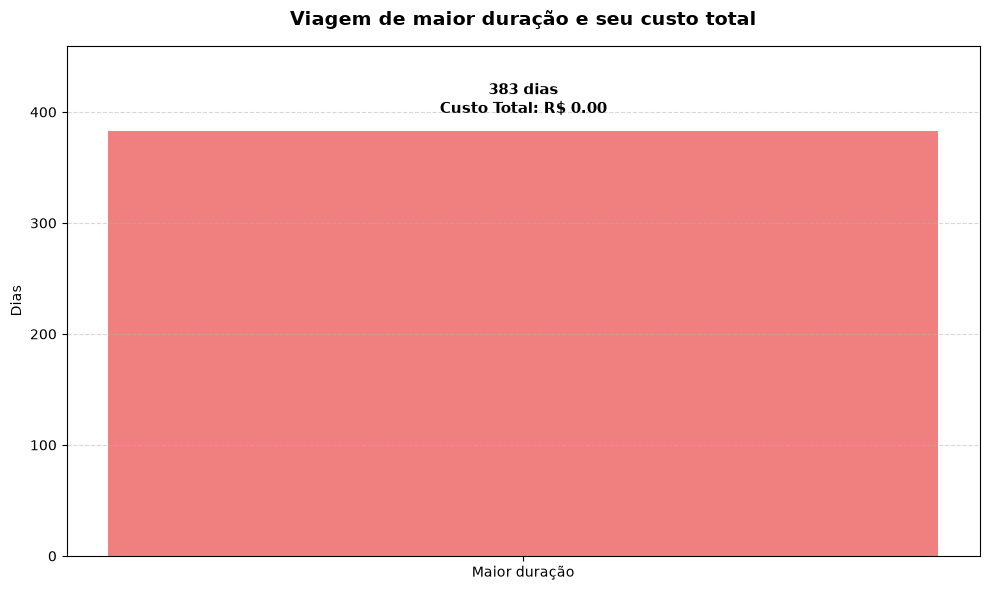

************************************************************************************************************************
                                               Exibição do Datrame Gerado                                                


In [ ]:

## Chamada da Função Analisar
df = analisar(3)

## Inicio da criação do gráfico
plt.figure(figsize=(10, 6))
plt.bar(["Maior duração"], df["duracao_dias"], color="lightcoral", width=0.5)
plt.title("Viagem de maior duração e seu custo total", fontsize=14, weight="bold", pad=15)
plt.ylabel("Dias")
plt.ylim(0, df["duracao_dias"].max() * 1.2)
plt.text(
    0,
    df["duracao_dias"].max() * 1.03,
    f"{df['duracao_dias'].max()} dias\nCusto Total: R$ {df['valor_total'].max():,.2f}",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold"
)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(f'{PASTA_IMAGE}/grafico_3.png', dpi=300, bbox_inches='tight')
plt.show()

## Apresentação do DF através do print e salvar em forma de imagem
print("".center(120, "*"))
print("Exibição do Datrame Gerado".center(120), "")
df.sort_values(by="duracao_dias", ascending=False)
dfi.export(
    df.sort_values(by="duracao_dias", ascending=False),
    f'{PASTA_IMAGE}/df_pergunta_3.png',
    table_conversion="matplotlib"
)
df

### Pergunta_4: Qual o tipo de pagamento com maior valor médio?


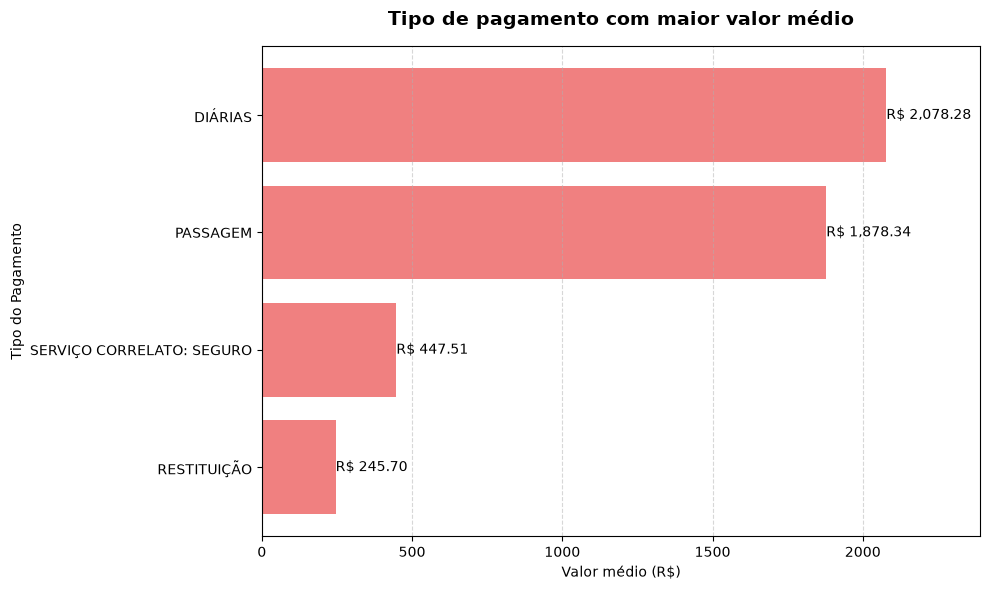

************************************************************************************************************************
                                               Exibição do Datrame Gerado                                                


,tipo_pagamento,valor_medio
0,DIÁRIAS,"2,078.28"
1,PASSAGEM,"1,878.34"
2,SERVIÇO CORRELATO: SEGURO,447.51
3,RESTITUIÇÃO,245.70


In [17]:
## Chamada da Função Analisar para a Pergunta 4
df = analisar(4)

## Criação do Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df["tipo_pagamento"], df["valor_medio"], color="lightcoral")
ax.invert_yaxis()
ax.set_title("Tipo de pagamento com maior valor médio", fontsize=14, weight="bold", pad=15)
ax.set_xlabel("Valor médio (R$)")
ax.set_ylabel("Tipo do Pagamento")
for i, valor in enumerate(df["valor_medio"]):
    ax.text(valor, i, f"R$ {valor:,.2f}", va="center", ha="left")
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.set_xlim(0, df["valor_medio"].max() * 1.15)
plt.tight_layout()
plt.savefig(f'{PASTA_IMAGE}/grafico_4.png', dpi=300, bbox_inches='tight')
plt.show()

## Apresentação do DF através do print e salvar em forma de imagem
print("".center(120, "*"))
print("Exibição do Datrame Gerado".center(120), "")
df.sort_values(by="valor_medio", ascending=False)
dfi.export(
    df.sort_values(by="valor_medio", ascending=False),
    f'{PASTA_IMAGE}/df_pergunta_4.png',
    table_conversion="matplotlib"
)
df

### Pergunta_5: Qual o meio de transporte mais usado nos trechos?


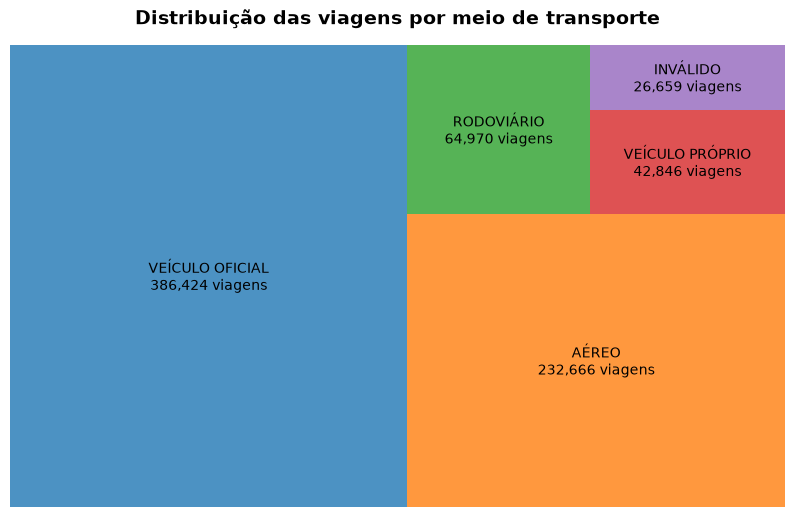

************************************************************************************************************************
                                               Exibição do Datrame Gerado                                                


,meio_transporte,qtde_viagens
0,VEÍCULO OFICIAL,386424
1,AÉREO,232666
2,RODOVIÁRIO,64970
3,VEÍCULO PRÓPRIO,42846
4,INVÁLIDO,26659


In [18]:

## Chamada da Função Analisar para a Pergunta 5
df = analisar(5)

## Criação do Gráfico
df = df.sort_values(
    "qtde_viagens",
    ascending=False
)
cores = plt.colormaps["tab10"](
    range(len(df))
)
plt.figure(figsize=(10, 6))
squarify.plot(
    sizes=df["qtde_viagens"],
    label=[
        f"{meio}\n{qtde:,.0f} viagens"
        for meio, qtde in zip(
            df["meio_transporte"],
            df["qtde_viagens"]
        )
    ],
    color=cores,
    alpha=0.8
)

plt.title("Distribuição das viagens por meio de transporte", fontsize=14, weight="bold", pad=15)
plt.axis("off")
plt.savefig(f'{PASTA_IMAGE}/grafico_5.png', dpi=300, bbox_inches='tight')
plt.show()

## Apresentação do DF através do print e salvar em forma de imagem
print("".center(120, "*"))
print("Exibição do Datrame Gerado".center(120), "")
df.sort_values(by="qtde_viagens", ascending=False)
dfi.export(
    df.sort_values(by="qtde_viagens", ascending=False),
    f'{PASTA_IMAGE}/df_pergunta_5.png',
    table_conversion="matplotlib"
)
df

### Pergunta_6: Qual UF de destino aparece em mais trechos?


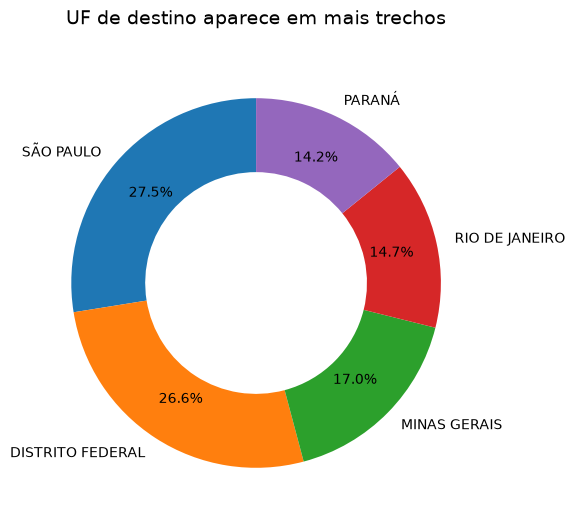

************************************************************************************************************************
                                               Exibição do Datrame Gerado                                                


,destino_uf,quantidade
0,SÃO PAULO,82722
1,DISTRITO FEDERAL,79962
2,MINAS GERAIS,50965
3,RIO DE JANEIRO,44197
4,PARANÁ,42603


In [20]:

## Chamada da Função Analisar para a Pergunta 6
df = analisar(6)

## Criação do Gráfico
plt.figure(figsize=(10, 6))
plt.pie(
    df["quantidade"],
    labels=df["destino_uf"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.4},
    pctdistance=0.75,    
    labeldistance=1.1    
)
plt.title(
    "UF de destino aparece em mais trechos",
    fontsize=14,
    pad=20
)
plt.savefig(f'{PASTA_IMAGE}/grafico_6.png', dpi=300, bbox_inches='tight')
plt.show()

## Apresentação do DF através do print e salvar em forma de imagem
print("".center(120, "*"))
print("Exibição do Datrame Gerado".center(120), "")
df.sort_values(by="quantidade", ascending=False)
dfi.export(
    df.sort_values(by="quantidade", ascending=False),
    f'{PASTA_IMAGE}/df_pergunta_6.png',
    table_conversion="matplotlib"
)
df

### Pergunta_7: Qual órgão pagou mais no total?

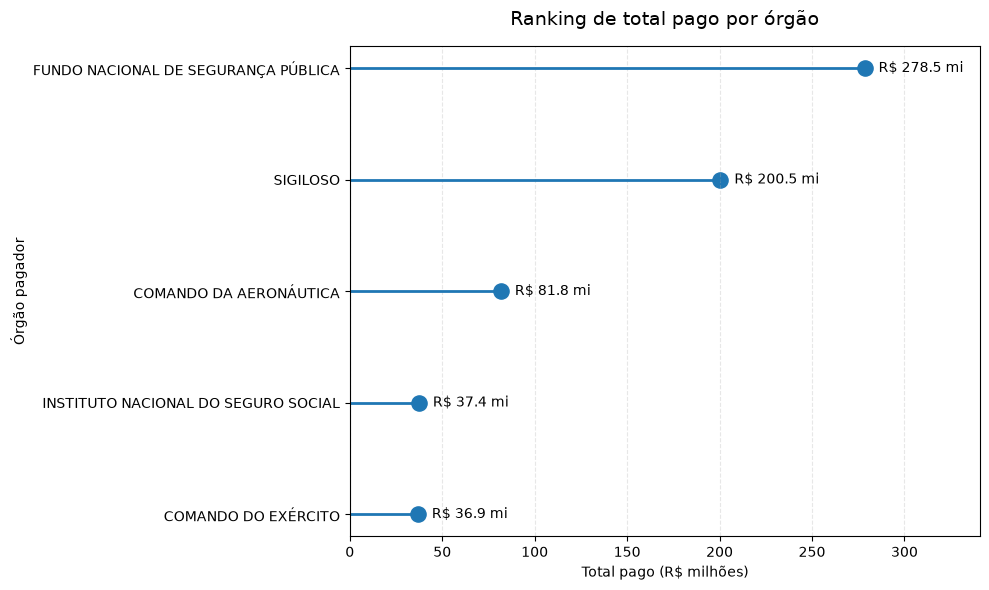

************************************************************************************************************************
                                               Exibição do Datrame Gerado                                                


,nome_orgao_pagador,total_pago
0,FUNDO NACIONAL DE SEGURANÇA PÚBLICA,"278,481,047.89"
1,SIGILOSO,"200,484,801.68"
2,COMANDO DA AERONÁUTICA,"81,769,144.77"
3,INSTITUTO NACIONAL DO SEGURO SOCIAL,"37,427,601.45"
4,COMANDO DO EXÉRCITO,"36,872,643.95"


In [24]:
## Chamada da Função Analisar para a Pergunta 7
df = analisar(7)

## Criação do Gráfico

df = df.sort_values(
    "total_pago",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.xlim(0, max_valor * 0.7)

plt.hlines(
    y=df["nome_orgao_pagador"],
    xmin=0,
    xmax=df["total_pago"],
    linewidth=2
)

plt.scatter(
    df["total_pago"],
    df["nome_orgao_pagador"],
    s=120
)

for valor, orgao in zip(
    df["total_pago"],
    df["nome_orgao_pagador"]
):
    plt.annotate(
        f"R$ {valor/1_000_000:.1f} mi",
        xy=(valor, orgao),
        xytext=(10, 0),
        textcoords="offset points",
        va="center",
        fontsize=10
    )

plt.title(
    "Ranking de total pago por órgão",
    fontsize=14,
    pad=15
)

plt.xlabel("Total pago (R$ milhões)")
plt.ylabel("Órgão pagador")

ax = plt.gca()
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1_000_000:.0f}")
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.savefig(f'{PASTA_IMAGE}/grafico_7.png', dpi=300, bbox_inches='tight')
plt.show()

## Apresentação do DF através do print e salvar em forma de imagem
print("".center(120, "*"))
print("Exibição do Datrame Gerado".center(120), "")
df.sort_values(by="total_pago", ascending=False)

df = df.sort_values(
    "total_pago",
    ascending=False
)

dfi.export(
    df,
    f'{PASTA_IMAGE}/df_pergunta_7.png',
    table_conversion="matplotlib"
)
df

### Pergunta_8:  Qual meio de transporte possui maior custo medio viagem?

Criando a GOLD da tabela gold_meio_transporte_maior_custo_medio_viagem
Criando a VIEW da tabela meio_transporte_maior_custo_medio_viagem


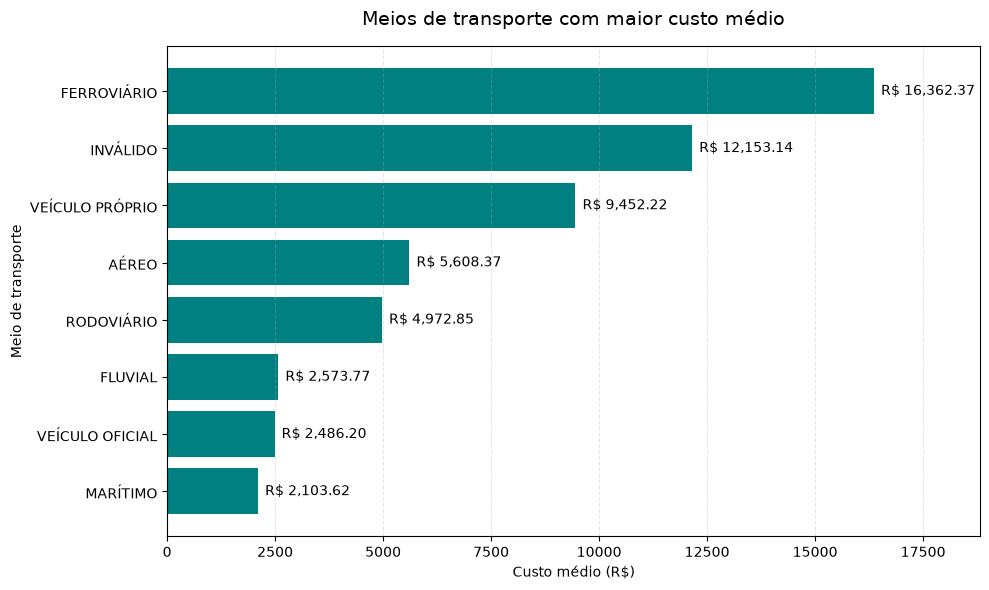

************************************************************************************************************************
                                               Exibição do Datrame Gerado                                                


,meio_transporte,custo_medio
0,FERROVIÁRIO,"16,362.37"
1,INVÁLIDO,"12,153.14"
2,VEÍCULO PRÓPRIO,"9,452.22"
3,AÉREO,"5,608.37"
4,RODOVIÁRIO,"4,972.85"
5,FLUVIAL,"2,573.77"
6,VEÍCULO OFICIAL,"2,486.20"
7,MARÍTIMO,"2,103.62"


In [51]:
## Chamada da Função Analisar para a Pergunta 8
df = analisar(8)

## Criando tabela Gold e View
criar_gold_view(8)

## Criação do Gráfico

# Ordenação para melhor visualização do gráfico
df = (
    df
    .sort_values(
        by="custo_medio",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(df["meio_transporte"], df["custo_medio"], color="teal")
ax.set_title("Meios de transporte com maior custo médio", fontsize=14, pad=15)
ax.set_xlabel("Custo médio (R$)")
ax.set_ylabel("Meio de transporte")

max_valor = df["custo_medio"].max()

for i, valor in enumerate(df["custo_medio"]):
    ax.text(
        valor + max_valor * 0.01,
        i,
        f"R$ {valor:,.2f}",
        va="center"
    )

ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_xlim(0, max_valor * 1.15)

plt.tight_layout()
plt.savefig(f"{PASTA_IMAGE}/grafico_8.png", dpi=300, bbox_inches="tight")
plt.show()

## Apresentação do DF através do print e salvar em forma de imagem
print("".center(120, "*"))
print("Exibição do Datrame Gerado".center(120), "")
df = df.sort_values(by="custo_medio",ascending=False)
dfi.export(df,f"{PASTA_IMAGE}/df_pergunta_8.png",table_conversion="matplotlib")
df

### Pergunta_9: Destinos com o maior custo total

Criando a GOLD da tabela gold_destinos_maior_custo_total
Criando a VIEW da tabela destinos_maior_custo_total


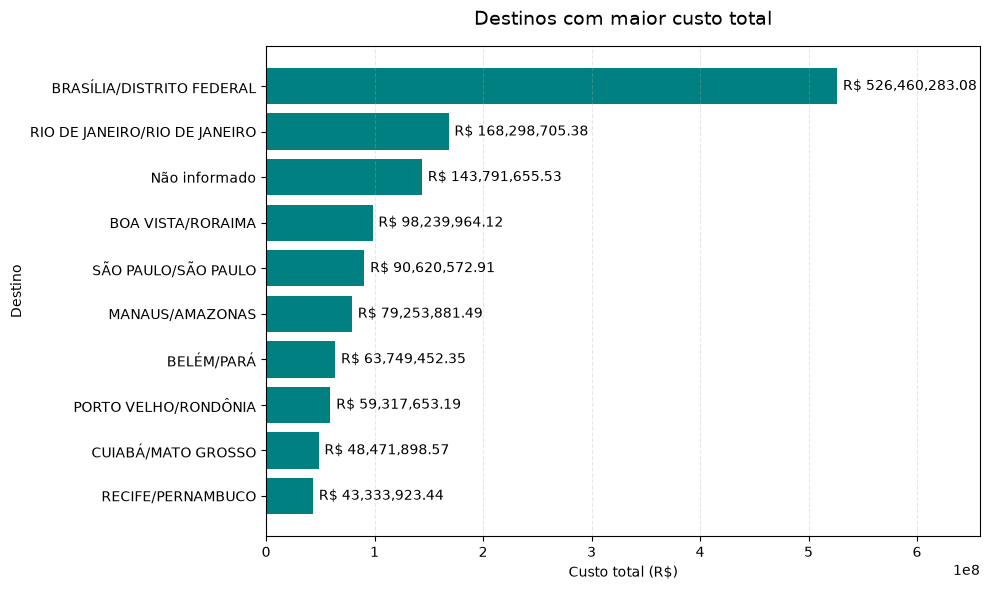

************************************************************************************************************************
                                               Exibição do Datrame Gerado                                                


,destino,custo_total
0,BRASÍLIA/DISTRITO FEDERAL,"526,460,283.08"
1,RIO DE JANEIRO/RIO DE JANEIRO,"168,298,705.38"
2,Não informado,"143,791,655.53"
3,BOA VISTA/RORAIMA,"98,239,964.12"
4,SÃO PAULO/SÃO PAULO,"90,620,572.91"
5,MANAUS/AMAZONAS,"79,253,881.49"
6,BELÉM/PARÁ,"63,749,452.35"
7,PORTO VELHO/RONDÔNIA,"59,317,653.19"
8,CUIABÁ/MATO GROSSO,"48,471,898.57"
9,RECIFE/PERNAMBUCO,"43,333,923.44"


In [60]:
# Chamada da Função Analisar
df = analisar(9)

# Criando tabela Gold e View
criar_gold_view(9)

# Correção: garantir que o eixo categórico seja texto
df["destino"] = df["destino"].fillna("Não informado").astype(str)

# Criação do Gráfico

# Ordenação para melhor visualização do gráfico
df = (
    df
    .sort_values(
        by="custo_total",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(df["destino"], df["custo_total"], color="teal")
ax.set_title("Destinos com maior custo total", fontsize=14, pad=15)
ax.set_xlabel("Custo total (R$)")
ax.set_ylabel("Destino")

max_valor = df["custo_total"].max()

for i, valor in enumerate(df["custo_total"]):
    ax.text(
        valor + max_valor * 0.01,
        i,
        f"R$ {valor:,.2f}",
        va="center"
    )

ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_xlim(0, max_valor * 1.25)

plt.tight_layout()
plt.savefig(f"{PASTA_IMAGE}/grafico_9.png", dpi=300, bbox_inches="tight")
plt.show()


# Apresentação do DF através do print e salvar em forma de imagem
print("".center(120, "*"))
print("Exibição do Datrame Gerado".center(120), "")
df.sort_values(by="custo_total", ascending=False)

### Pergunta_10: Viajantes maior custo total

Criando a GOLD da tabela gold_viajantes_maior_custo_total
Criando a VIEW da tabela viajantes_maior_custo_total


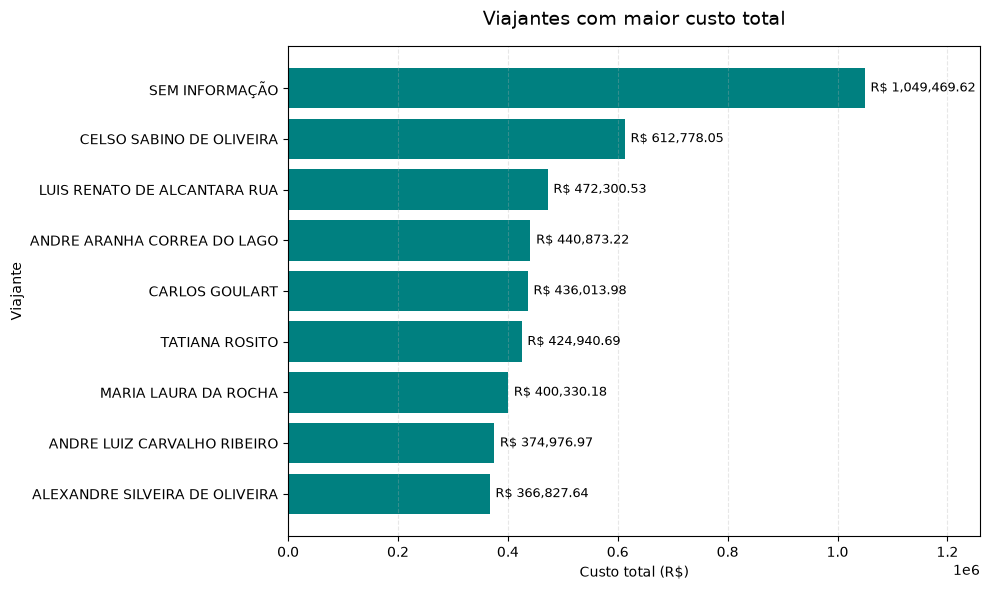

************************************************************************************************************************
                                               Exibição do Datrame Gerado                                                


,nome_viajante,quantidade_viagens,custo_total
0,INFORMAÇÕES PROTEGIDAS POR SIGILO,51315,"199,435,332.06"
1,SEM INFORMAÇÃO,235,"1,049,469.62"
2,CELSO SABINO DE OLIVEIRA,27,"612,778.05"
3,LUIS RENATO DE ALCANTARA RUA,14,"472,300.53"
4,ANDRE ARANHA CORREA DO LAGO,10,"440,873.22"
5,CARLOS GOULART,17,"436,013.98"
6,TATIANA ROSITO,9,"424,940.69"
7,MARIA LAURA DA ROCHA,7,"400,330.18"
8,ANDRE LUIZ CARVALHO RIBEIRO,36,"374,976.97"
9,ALEXANDRE SILVEIRA DE OLIVEIRA,20,"366,827.64"


In [61]:
## Chamada da Função Analisar
df = analisar(10)

## Criando tabela Gold e View
criar_gold_view(10)

## Criação do Gráfico

# Removendo registros sem identificação nominal
df_grafico = (
    df[df["nome_viajante"] != "INFORMAÇÕES PROTEGIDAS POR SIGILO"]
    .sort_values(
        by="custo_total",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    df_grafico["nome_viajante"],
    df_grafico["custo_total"],
    color="teal"
)

ax.set_title(
    "Viajantes com maior custo total",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Custo total (R$)")
ax.set_ylabel("Viajante")

max_valor = df_grafico["custo_total"].max()

for i, valor in enumerate(df_grafico["custo_total"]):
    ax.text(
        valor + max_valor * 0.01,
        i,
        f"R$ {valor:,.2f}",
        va="center",
        fontsize=9
    )

ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_xlim(0, max_valor * 1.20)

plt.tight_layout()
plt.show()


## Apresentação do DF através do print e salvar em forma de imagem
print("".center(120, "*"))
print("Exibição do Datrame Gerado".center(120), "")
df.sort_values(by="custo_total", ascending=False)